In [1]:
import torch
from torch import nn
from torch.nn import functional as F

import numpy as np

import pickle

from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt

In [2]:
Path.cwd().parent / 'experiment_data'

WindowsPath('d:/College 2/sem 3/LTH/code/lth-efficiency/experiment_data')

In [3]:
experiment_folder = Path.cwd().parent / 'experiment_data'

In [102]:
network_file = experiment_folder / 'subnetworks-e50-r10-p0.2000-t15-s32.pkl'

In [103]:
with open(network_file, 'rb') as f:
    results = pickle.load(f)

In [104]:
pprint(list(results.keys()))

['seeds',
 'config',
 'FC-train-losses',
 'FC-train-accs',
 'FC-test-losses',
 'FC-test-accs',
 'winning-tickets',
 'winning-tickets-full-initializations',
 'winning-ticket-masks',
 'pruned-train-loss-before',
 'pruned-train-acc-before',
 'pruned-test-loss-before',
 'pruned-test-acc-before',
 'pruned-train-loss-after',
 'pruned-train-acc-after',
 'pruned-test-loss-after',
 'pruned-test-acc-after']


In [105]:
net1 = results['winning-tickets'][0]
net2 = results['winning-tickets'][1]

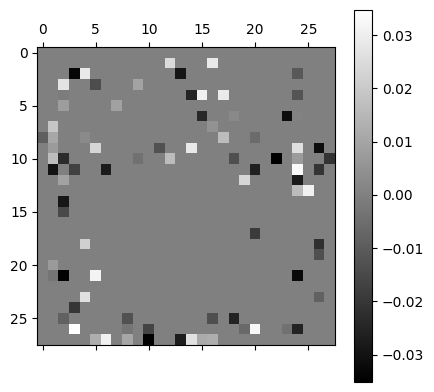

In [137]:
cax = plt.matshow(results['winning-tickets'][10]['1.weight'].reshape((32, 28, 28))[17], cmap='grey')
plt.colorbar(cax)

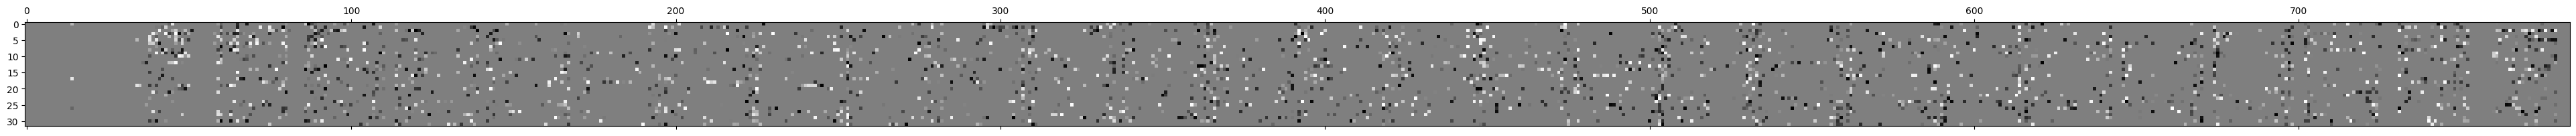

In [107]:
plt.matshow(net2['1.weight'], cmap='grey')
plt.gcf().set_figwidth(100)

In [108]:
def compare_first_layer(net1: nn.Module, net2: nn.Module):
    assert net1.keys() == net2.keys()

    weight_vec_1 = torch.concat([net1['1.weight'], net1['1.bias'].unsqueeze(dim=1)], dim=1)
    weight_vec_2 = torch.concat([net2['1.weight'], net2['1.bias'].unsqueeze(dim=1)], dim=1)

    similarity_mat = torch.matmul(F.normalize(weight_vec_1, p=2, dim=1), F.normalize(weight_vec_2, p=2, dim=1))
    print(similarity_mat)

# compare_first_layer(net1, net2)

In [109]:
from scipy.optimize import linear_sum_assignment

def compare_first_layer(net1: nn.Module, net2: nn.Module):
    assert net1.keys() == net2.keys()

    weight_vec_1 = torch.concat([net1['1.weight'], net1['1.bias'].unsqueeze(dim=1)], dim=1)
    weight_vec_2 = torch.concat([net2['1.weight'], net2['1.bias'].unsqueeze(dim=1)], dim=1)

    similarity_mat = torch.matmul(F.normalize(weight_vec_1, p=2, dim=1), F.normalize(weight_vec_2, p=2, dim=1).T)

    # assert torch.allclose(similarity_mat.diag(), F.cosine_similarity(weight_vec_1, weight_vec_2))

    cost_mat = -similarity_mat
    row_ind, col_ind = linear_sum_assignment(cost_mat)
    
    best_costs = similarity_mat[row_ind, col_ind]
    mean_sim = torch.mean(best_costs)

    return mean_sim
    

compare_first_layer(net1, net2)

tensor(0.0865)

In [110]:
test_mat = torch.rand(size=(3, 5))

In [111]:
(test_mat[torch.arange(test_mat.shape[0]), :] == test_mat).all()

tensor(True)

In [112]:
test_mat

tensor([[0.3518, 0.1097, 0.5211, 0.8632, 0.9551],
        [0.0891, 0.0706, 0.5740, 0.9942, 0.5078],
        [0.5285, 0.5920, 0.6957, 0.9866, 0.5687]])

In [113]:
test_mat[torch.randperm(test_mat.shape[0]), :]

tensor([[0.5285, 0.5920, 0.6957, 0.9866, 0.5687],
        [0.0891, 0.0706, 0.5740, 0.9942, 0.5078],
        [0.3518, 0.1097, 0.5211, 0.8632, 0.9551]])

In [114]:
A = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
B = torch.tensor([[9,8,7],[6,5,4],[3,2,1]])

print(A)
print(B)
print(torch.matmul(A, B.T))

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
tensor([[9, 8, 7],
        [6, 5, 4],
        [3, 2, 1]])
tensor([[ 46,  28,  10],
        [118,  73,  28],
        [190, 118,  46]])


In [115]:
def mean_cossim_layer(net1: nn.Module, net2: nn.Module, layer, alignment = None):
    '''
    `alignment` should be a list, ndarray or tensor that contains an alignment from net1 to net2
    i.e. if index i contains value j, then input i in net1[layer] is mapped to input j in net2[layer].
    Both net1[layer] and net2[layer] MUST be torch.nn.Linear ONLY.
    '''

    

    # weight_vec_1 = torch.rand(size=(3, 5))
    # weight_vec_2 = torch.rand(size=(3, 5))
    
    weight_vec_1 = net1[f'{layer}.weight']
    weight_vec_2 = net2[f'{layer}.weight']

    if alignment is None:
        alignment = torch.arange(weight_vec_1.shape[1])
    
    assert (np.array(alignment).shape[0] == weight_vec_1.shape[1]), f'{weight_vec_1.shape=}, {alignment.shape=}'

    weight_vec_2 = weight_vec_2[:, alignment]

    weight_vec_1 = torch.concat([net1[f'{layer}.weight'], net1[f'{layer}.bias'].unsqueeze(dim=1)], dim=1)
    weight_vec_2 = torch.concat([net2[f'{layer}.weight'], net2[f'{layer}.bias'].unsqueeze(dim=1)], dim=1)
    
    similarity_mat = torch.matmul(F.normalize(weight_vec_1, p=2, dim=1), F.normalize(weight_vec_2, p=2, dim=1).T)

    assert torch.allclose(similarity_mat.diag(), F.cosine_similarity(weight_vec_1, weight_vec_2))

    cost_mat = -similarity_mat
    row_ind, col_ind = linear_sum_assignment(cost_mat)
    
    best_sims = similarity_mat[row_ind, col_ind]
    mean_sim = torch.mean(best_sims)

    return mean_sim, col_ind

def mean_cossim_layer_fixed_identities(net1, net2, layer, alignment = None):
    '''
    Basically the same as `mean_cossim_layer` but assumes that the current neurons are one-to-one, so skips the linear sum assignment.
    Note however it does NOT assume the same about the previous layer so it still requires an alignment vector. Still returns a `None` in place of a forward alignment 
    to be consistent.
    '''

    weight_vec_1 = net1[f'{layer}.weight']
    weight_vec_2 = net2[f'{layer}.weight']

    if alignment is None:
        alignment = torch.arange(weight_vec_1.shape[1])
    
    assert (np.array(alignment).shape[0] == weight_vec_1.shape[1]), f'{weight_vec_1.shape=}, {alignment.shape=}'

    weight_vec_2 = weight_vec_2[:, alignment]

    weight_vec_1 = torch.concat([net1[f'{layer}.weight'], net1[f'{layer}.bias'].unsqueeze(dim=1)], dim=1)
    weight_vec_2 = torch.concat([net2[f'{layer}.weight'], net2[f'{layer}.bias'].unsqueeze(dim=1)], dim=1)
    
    # similarity_mat = torch.matmul(F.normalize(weight_vec_1, p=2, dim=1), F.normalize(weight_vec_2, p=2, dim=1).T)
    best_sims = F.cosine_similarity(weight_vec_1, weight_vec_2)
    mean_sim = torch.mean(best_sims)

    return mean_sim, None


mean_cossim_layer_fixed_identities(net1, net2, 3, alignment=None)
    

C:\Users\Sukrit\AppData\Local\Temp\ipykernel_19924\975836974.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  assert (np.array(alignment).shape[0] == weight_vec_1.shape[1]), f'{weight_vec_1.shape=}, {alignment.shape=}'


(tensor(0.0319), None)

In [116]:
def compute_net_similarity(net1, net2):
    layers = list(net1.keys())
    layers = map(lambda x: x.split('.')[0], layers)
    layers = list(set(layers))
    layers.sort()
    alignment = None
    
    means = []
    for i, layer in enumerate(layers):
        if i == len(layers) - 1: break
        
        layer_sim_mean, alignment = mean_cossim_layer(net1, net2, layer, alignment=alignment)
        means.append(layer_sim_mean)

    layer_sim_mean, _ = mean_cossim_layer_fixed_identities(net1, net2, layers[-1], alignment=alignment)
    means.append(layer_sim_mean)
    return np.mean(means)

compute_net_similarity(net1, net2)

C:\Users\Sukrit\AppData\Local\Temp\ipykernel_19924\975836974.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  assert (np.array(alignment).shape[0] == weight_vec_1.shape[1]), f'{weight_vec_1.shape=}, {alignment.shape=}'


np.float32(0.059188426)

In [128]:
sims = []

for _ in range(1000000):
    v1, v2 = np.random.uniform(-1, 1, size=784), np.random.uniform(-1, 1, size=784)
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    sims.append(cos_sim)

print(np.var(sims), 1/784)

0.0012747919316611579 0.0012755102040816326


In [133]:
similarities = []

for i, net1 in enumerate(results['winning-tickets']):
    for j, net2 in enumerate(results['winning-tickets']):
        if i == j: continue
         
        similarities.append(compare_first_layer(net1, net2))

mean_net_sim = np.mean(similarities)
std_net_sim = np.std(similarities)
print(mean_net_sim)
print(std_net_sim)

0.08213085
0.004978329


In [134]:
pprint(similarities)

[tensor(0.0865),
 tensor(0.0852),
 tensor(0.0830),
 tensor(0.0869),
 tensor(0.0822),
 tensor(0.0839),
 tensor(0.0822),
 tensor(0.0780),
 tensor(0.0885),
 tensor(0.0888),
 tensor(0.0767),
 tensor(0.0781),
 tensor(0.0812),
 tensor(0.0838),
 tensor(0.0865),
 tensor(0.0878),
 tensor(0.0876),
 tensor(0.0892),
 tensor(0.0852),
 tensor(0.0862),
 tensor(0.0886),
 tensor(0.0785),
 tensor(0.0916),
 tensor(0.0851),
 tensor(0.0875),
 tensor(0.0763),
 tensor(0.0843),
 tensor(0.0854),
 tensor(0.0852),
 tensor(0.0878),
 tensor(0.0859),
 tensor(0.0929),
 tensor(0.0854),
 tensor(0.0799),
 tensor(0.0807),
 tensor(0.0816),
 tensor(0.0808),
 tensor(0.0885),
 tensor(0.0811),
 tensor(0.0771),
 tensor(0.0886),
 tensor(0.0841),
 tensor(0.0830),
 tensor(0.0876),
 tensor(0.0859),
 tensor(0.0875),
 tensor(0.0813),
 tensor(0.0841),
 tensor(0.0795),
 tensor(0.0873),
 tensor(0.0891),
 tensor(0.0948),
 tensor(0.0951),
 tensor(0.0725),
 tensor(0.0814),
 tensor(0.0904),
 tensor(0.0869),
 tensor(0.0892),
 tensor(0.0929

In [120]:


values = []
for _ in range(1000):
    similarity_mat = np.random.normal(0, 1/np.sqrt(784), size=(32, 32)) #TODO: is 1/sqrt(n) the correct stddev? validate.
    cost_mat = -similarity_mat
    row_ind, col_ind = linear_sum_assignment(cost_mat)

    best_costs = similarity_mat[row_ind, col_ind]
    mean_sim = np.mean(best_costs)
    values.append(mean_sim)

print(np.mean(values))
print(np.std(values))
print(f'95% conf int: {np.mean(values) - 1.645*np.std(values)} -- {np.mean(values) + 1.645*np.std(values)}')

0.06699134224004841
0.002917634015844988
95% conf int: 0.0621918342839834 -- 0.0717908501961134


In [121]:
print(f'MEAN SIMILARITY = {mean_net_sim}')

MEAN SIMILARITY = 0.08213084936141968


In [127]:
print(f'{(0.08213084936141968 - 0.06699134224004841) / 0.002917634015844988:.1f}σ result')

5.2σ result
